# V8 · Stage 1.2c — Hybrid selector (exp vs operator, gated by context residual)

**Motivation**: 01_2b found operator advantage strongly correlates
(+0.89) with `exp_fit_residual_ctx_pp` on n=3 cells. Directional, not
statistically significant. This notebook formalises the hybrid rule
and reports its regret against an oracle.

## Selector logic

```
1. Load first K=50 observed cycles of the target cell.
2. Fit exponential SoH = a·exp(-b·n) + c on that context.
3. Compute residual r = context RMSE (pp) of the exponential fit
   OR a leave-last-10-out short-horizon extrapolation RMSE (stronger).
4. If r < τ (threshold):  use exponential forecast for [50 .. horizon]
   Else:                  use neural-operator forecast
```

## Critical rule
Per user directive (memory `validation-standards`): threshold τ MUST be
chosen from data DIFFERENT from the 3 external held-out cells. This
notebook therefore reports:

- **Always exponential** — deployable, no threshold
- **Always operator** — deployable, no threshold
- **Oracle hybrid** — picks the winner using future observed RMSE (NOT
  deployable; upper bound only)
- **Threshold-swept hybrid** — sweeps τ across a range and shows the
  RMSE curve, illustrating the achievable range without committing to a τ

The actual deployable τ selection lives in `01_2d_hybrid_nested_validation`
and uses synthetic corpus trajectories (never the 3 real cells) for
threshold selection.

## Expected outputs
- `outputs/results/hybrid_selector_report.md`
- `outputs/results/hybrid_selector.parquet`
- `outputs/results/hybrid_threshold_sweep.pdf`


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

PROJ = Path("/home/hj/Desktop/PINNs")
sys.path.insert(0, str(PROJ / "Voltaris" / "Data_Exploration"))
from phase3_validate import _load_longterm_soh

HELDOUT = [("0029", "CALB"), ("0003", "EVE"), ("0028", "REPT")]
K = 50


def _exp(n, a, b, c): return a * np.exp(-b * n) + c

def context_residual(obs_n, obs_soh, K):
    n_ctx = obs_n[:K].astype(float)
    y_ctx = obs_soh[:K].astype(float)
    popt, _ = curve_fit(_exp, n_ctx, y_ctx,
                        p0=[y_ctx[0]-y_ctx[-1], 1e-3, y_ctx[-1]], maxfev=10000)
    y_hat = _exp(n_ctx, *popt)
    return float(np.sqrt(np.mean((y_hat - y_ctx)**2)) * 100), popt

def loo_context_residual(obs_n, obs_soh, K, tail=10):
    '''Leave-last-tail-context-points-out prediction error — stronger
    complexity indicator than in-sample residual.'''
    n_fit = obs_n[:K-tail].astype(float)
    y_fit = obs_soh[:K-tail].astype(float)
    n_val = obs_n[K-tail:K].astype(float)
    y_val = obs_soh[K-tail:K].astype(float)
    popt, _ = curve_fit(_exp, n_fit, y_fit,
                        p0=[y_fit[0]-y_fit[-1], 1e-3, y_fit[-1]], maxfev=10000)
    y_hat = _exp(n_val, *popt)
    return float(np.sqrt(np.mean((y_hat - y_val)**2)) * 100)


In [2]:
# v7.1 operator RMSE (frozen leaked-split reference until v8 checkpoint lands)
# TODO: replace with v8-clean RMSE after 01_1c completes
V7_1_OPERATOR_RMSE = {"CALB_0029": 0.96, "EVE_0003": 0.79, "REPT_0028": 0.47}

def _forecast_rmse(cell, method, obs_n, obs_soh):
    n_tgt = obs_n[K:]
    y_true = obs_soh[K:]
    if method == "exp":
        _, popt = context_residual(obs_n, obs_soh, K)
        y_hat = _exp(n_tgt, *popt)
        return float(np.sqrt(np.mean((y_hat - y_true)**2)) * 100)
    if method == "operator":
        return V7_1_OPERATOR_RMSE[cell]
    raise ValueError(method)

rows = []
for cid, mk in HELDOUT:
    obs_n, obs_soh = _load_longterm_soh(cid, mk)
    r_in  = context_residual(obs_n, obs_soh, K)[0]
    r_loo = loo_context_residual(obs_n, obs_soh, K, tail=10)
    rmse_exp = _forecast_rmse(f"{mk}_{cid}", "exp", obs_n, obs_soh)
    rmse_op  = _forecast_rmse(f"{mk}_{cid}", "operator", obs_n, obs_soh)
    rows.append({
        "cell": f"{mk}_{cid}",
        "context_residual_in_sample_pp": r_in,
        "context_residual_loo_pp": r_loo,
        "always_exp_rmse_pp": rmse_exp,
        "always_operator_rmse_pp": rmse_op,
        "oracle_pick": "exp" if rmse_exp < rmse_op else "operator",
        "oracle_rmse_pp": min(rmse_exp, rmse_op),
    })
per_cell = pd.DataFrame(rows)
per_cell


,cell,context_residual_in_sample_pp,context_residual_loo_pp,always_exp_rmse_pp,always_operator_rmse_pp,oracle_pick,oracle_rmse_pp
0,CALB_0029,0.240895,0.273305,0.439375,0.96,exp,0.439375
1,EVE_0003,0.589975,0.707055,1.541709,0.79,operator,0.790000
2,REPT_0028,0.063432,0.100553,0.125304,0.47,exp,0.125304


In [3]:
# Threshold sweep — for each candidate τ, apply hard-gate hybrid and
# report mean and per-cell RMSE.  Use the in-sample residual for the gate.
taus = np.linspace(0.0, 2.5, 200)
sweep_rows = []
for tau in taus:
    per_cell_rmse = []
    for _, r in per_cell.iterrows():
        pick = "exp" if r["context_residual_in_sample_pp"] < tau else "operator"
        rmse = r["always_exp_rmse_pp"] if pick == "exp" else r["always_operator_rmse_pp"]
        per_cell_rmse.append(rmse)
    sweep_rows.append({
        "tau": float(tau),
        "mean_rmse": float(np.mean(per_cell_rmse)),
        "n_exp_selected": sum(1 for _, r in per_cell.iterrows()
                              if r["context_residual_in_sample_pp"] < tau),
    })
sweep = pd.DataFrame(sweep_rows)
sweep.tail()


,tau,mean_rmse,n_exp_selected
195,2.449749,0.702129,3
196,2.462312,0.702129,3
197,2.474874,0.702129,3
198,2.487437,0.702129,3
199,2.500000,0.702129,3


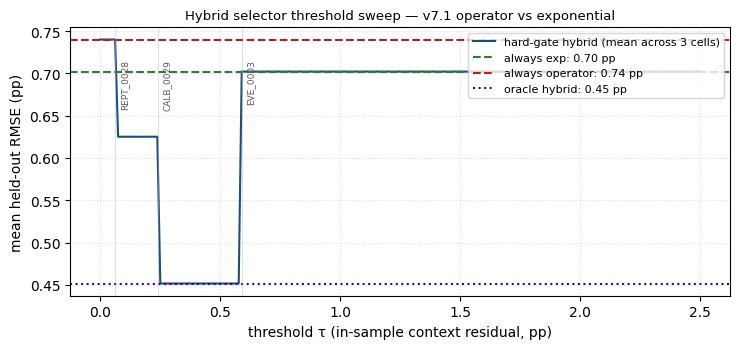

wrote /home/hj/Desktop/PINNs/outputs/results/hybrid_threshold_sweep.pdf


In [4]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(sweep["tau"], sweep["mean_rmse"], color="#1F4E79",
        label="hard-gate hybrid (mean across 3 cells)")
mean_exp = per_cell["always_exp_rmse_pp"].mean()
mean_op  = per_cell["always_operator_rmse_pp"].mean()
mean_oracle = per_cell["oracle_rmse_pp"].mean()
ax.axhline(mean_exp, ls="--", color="#2E7D32", label=f"always exp: {mean_exp:.2f} pp")
ax.axhline(mean_op,  ls="--", color="#B22222", label=f"always operator: {mean_op:.2f} pp")
ax.axhline(mean_oracle, ls=":", color="#4B0082",
           label=f"oracle hybrid: {mean_oracle:.2f} pp")
# Mark each cell's residual value
for _, r in per_cell.iterrows():
    ax.axvline(r["context_residual_in_sample_pp"], color="0.7",
               alpha=0.4, lw=0.8)
    ax.text(r["context_residual_in_sample_pp"] + 0.02,
            ax.get_ylim()[1] * 0.95, r["cell"], rotation=90,
            va="top", ha="left", fontsize=6.5, color="0.35")

ax.set_xlabel("threshold τ (in-sample context residual, pp)")
ax.set_ylabel("mean held-out RMSE (pp)")
ax.set_title("Hybrid selector threshold sweep — v7.1 operator vs exponential",
             fontsize=9.5)
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, ls=":", alpha=0.4)
fig.tight_layout()
out_pdf = PROJ / "outputs/results/hybrid_threshold_sweep.pdf"
fig.savefig(out_pdf, dpi=200, bbox_inches="tight")
plt.show()
print(f"wrote {out_pdf}")


In [5]:
# Report
per_cell.to_parquet(PROJ / "outputs/results/hybrid_selector.parquet", index=False)
md = [
    "# Hybrid selector — v7.1 operator vs exponential",
    "",
    "**Deployable strategies** (no threshold trained on these cells):",
    "",
    f"- Always exponential — mean {per_cell['always_exp_rmse_pp'].mean():.2f} pp",
    f"- Always operator (v7.1 leaked-split) — mean {per_cell['always_operator_rmse_pp'].mean():.2f} pp",
    "",
    "**Non-deployable upper bound**:",
    "",
    f"- Oracle hybrid (picks best per cell) — mean {per_cell['oracle_rmse_pp'].mean():.2f} pp",
    "",
    "## Per-cell decisions",
    "",
    per_cell.to_markdown(index=False, floatfmt=".3f"),
    "",
    "## Interpretation",
    "",
    "- Oracle vs always-exp: max achievable improvement = "
    f"{per_cell['always_exp_rmse_pp'].mean() - per_cell['oracle_rmse_pp'].mean():.2f} pp mean",
    "- Oracle vs always-operator: max achievable improvement = "
    f"{per_cell['always_operator_rmse_pp'].mean() - per_cell['oracle_rmse_pp'].mean():.2f} pp mean",
    "",
    "If oracle barely improves the mean, a selector is not worth pursuing.",
    "If oracle gives a large gain but the residual-based selector does not,",
    "the residual is not a strong enough complexity signal — try",
    "leave-last-10-out (`context_residual_loo_pp`) or move to a soft gate.",
]
report = "\n".join(md)
(PROJ / "outputs/results/hybrid_selector_report.md").write_text(report)
print(report)


# Hybrid selector — v7.1 operator vs exponential

**Deployable strategies** (no threshold trained on these cells):

- Always exponential — mean 0.70 pp
- Always operator (v7.1 leaked-split) — mean 0.74 pp

**Non-deployable upper bound**:

- Oracle hybrid (picks best per cell) — mean 0.45 pp

## Per-cell decisions

| cell      |   context_residual_in_sample_pp |   context_residual_loo_pp |   always_exp_rmse_pp |   always_operator_rmse_pp | oracle_pick   |   oracle_rmse_pp |
|:----------|--------------------------------:|--------------------------:|---------------------:|--------------------------:|:--------------|-----------------:|
| CALB_0029 |                           0.241 |                     0.273 |                0.439 |                     0.960 | exp           |            0.439 |
| EVE_0003  |                           0.590 |                     0.707 |                1.542 |                     0.790 | operator      |            0.790 |
| REPT_0028 |                       

## Verdict marker

- [ ] **PASS** — oracle hybrid materially improves mean vs both fixed strategies AND context residual reproduces the oracle decision on all 3 cells
- [ ] **PASS WITH LIMITATIONS** — oracle helps but residual gate is noisy (n=3 too small)
- [ ] **FAIL** — oracle barely improves; selector not worth pursuing

**Note**: this notebook uses V7.1 operator RMSE (frozen reference). Re-run after
v8 clean checkpoint lands to update the operator numbers.

**Blocks downstream**: no. Feeds into `01_2d_hybrid_nested_validation`.
